# Машинное обучение. ВМК МГУ

# Практическое задание 5: Линейные модели: регрессия

## Уровень: **Базовый (Base)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

Цель данного задания:

- Узнать, что такое регуляризация, зачем она нужна, и чем отличаются разные регуляризаторы.
- Научиться решать задачу регрессии линейными моделями.

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: 5 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.05MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Линейная регрессия и регуляризация

Напомним, что **линейная регрессия** — это модель следующего вида: a ( x ) = ⟨ w , x ⟩ + b a ( x ) = ⟨ w , x ⟩ + b где w ∈ R d w ∈ R d , b ∈ R b ∈ R . Обучить линейную регрессию — значит найти w w и b b .

Для обучения линейной регрессии, равно как и для обучения остальных
простых моделей (линейные модели, решающие деревья, knn и т.д.) отлично
подходит библиотека scikit-learn (sklearn): в ней очень понятный и простой интерфейс.

Однако для обучения более сложных моделей вроде бустинга и нейронных
сетей всё же нужно пользоваться специализированными библиотеками:
XGBoost, LightGBM, CatBoost и пр. для градиентного бустинга над
деревьями, PyTorch, Tensorflow и пр. для нейронных сетей.

Напомним, что линейная регрессия — это модель вида

a ( x ) = ⟨ w , x ⟩ + b a ( x ) = ⟨ w , x ⟩ + b

где w ∈ R d w ∈ R d , b ∈ R b ∈ R . Для обучения параметров w w решается оптимизационная задача следующего вида:

1 M ∑ M i = 1 ( w 1 ⋅ x i 1 + ⋯ + w n ⋅ x i n + b − y i ) 2 + α ⋅ R ( w ) → min w 1 , … , w n , b 1 M ∑ i = 1 M ( w 1 ⋅ x i 1 + ⋯ + w n ⋅ x i n + b − y i ) 2 + α ⋅ R ( w ) → min w 1 , … , w n , b

Здесь R ( w ) R ( w ) — это регуляризация параметров модели, α α — коэффициент регуляризации, задаваемый перед началом обучения.

Для обучения линейной регрессии, нам подойдет реализация из sklearn. В
sklearn есть несколько классов, реализующих линейную регрессию.
Основные это:

- LinearRegression — линейная регрессия без регуляризации R ( w ) = 0 R ( w ) = 0 (метод наименьших квадратов)
- Ridge — линейная регрессия с оптимизацией MSE и ℓ 2 ℓ 2 -регуляризацией R ( w ) = 1 2 ⋅ ( w 2 1 + ⋯ + w 2 n ) R ( w ) = 1 2 ⋅ ( w 1 2 + ⋯ + w n 2 )
- Lasso — линейная регрессия с оптимизацией MSE и ℓ 1 ℓ 1 -регуляризацией R ( w ) = | w 1 | + ⋯ + | w n | R ( w ) = | w 1 | + ⋯ + | w n |

Также есть SVR, ElasticNet и пр., но не будем сегодня о них

У моделей из sklearn есть методы fit и predict. Первый принимает на
вход обучающую выборку и вектор целевых переменных и обучает модель,
второй, будучи вызванным после обучения модели, возвращает предсказание
на выборке.

Рассмотрим, модельные данные для задачи регрессии. Пусть x x будет обычным числом из равномерного распределения, а y = 0.5 ⋅ x + 0.1 y = 0.5 ⋅ x + 0.1 — целевая переменная. При этом наблюдаем мы ¯ ¯ ¯ y = y + ε , ε ∼ N ( 0 , 0.01 ) y ¯ = y + ε , ε ∼ N ( 0 , 0.01 ) .

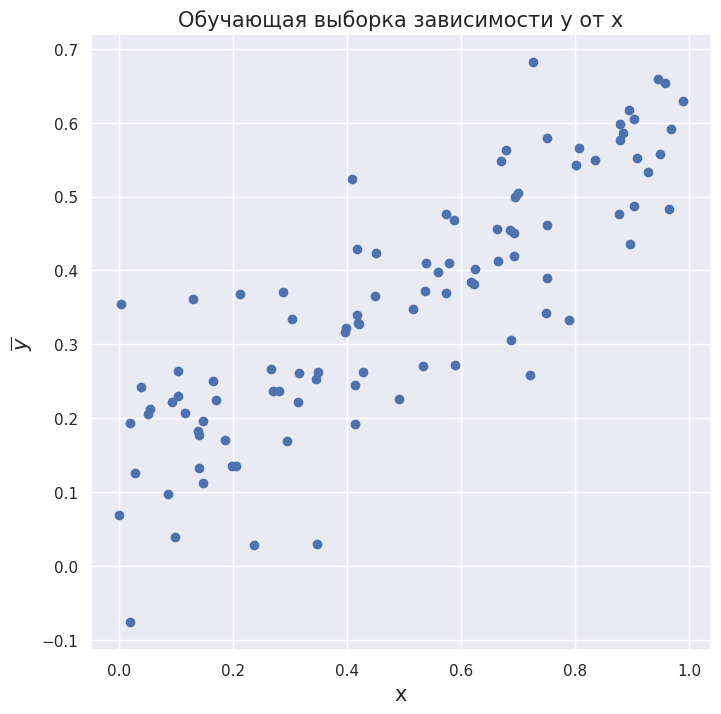

In [ ]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = X * 0.5 + 0.1 + np.random.randn(100) * 0.1

plt.figure(figsize=(8, 8))
plt.scatter(X, Y)
plt.title("Обучающая выборка зависимости y от x", size=15)
plt.xlabel("x", size=15)
plt.ylabel(r'$\overline{y}$', size=15)
plt.show()

**Обучим** линейную регрессию с l 2 l 2 регуляризацией, и посмотрим как регуляризация влияет на качество модели. В реализации библиотеки sklearn (класс Ridge) коэффициент регуляризации задаётся параметром alpha

In [ ]:
from sklearn.linear_model import Ridge

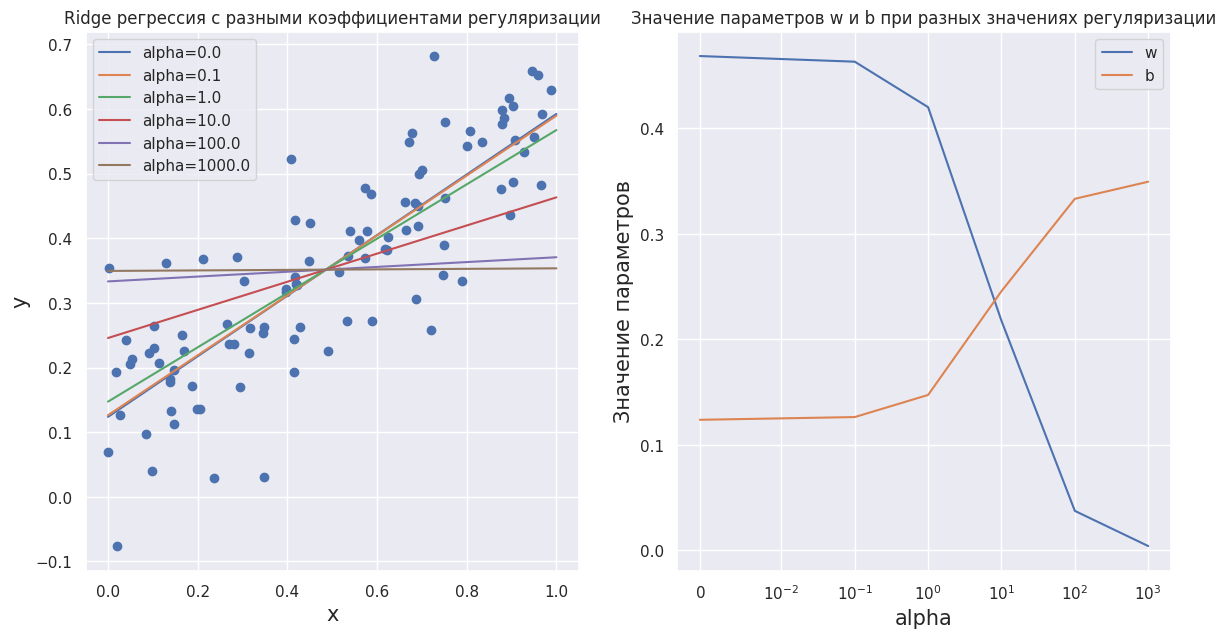

In [ ]:
x_axis = np.linspace(0, 1, 200)
fig, axs = plt.subplots(figsize=(14, 7), ncols=2)
axs[0].scatter(X, Y)

w = []
b = []

alphas = [0.0, 0.1, 1.0, 10.0, 100.0, 1000.0]

for alpha in alphas:
    reg = Ridge(alpha=alpha) # Задаем параметр alpha
    reg.fit(X[:, None], Y)
    pred = reg.predict(x_axis[:, None])
    w.append(reg.coef_[0])
    b.append(reg.intercept_)
    axs[0].plot(x_axis, pred, label="alpha=" + str(alpha))

axs[0].legend()
axs[0].set_xlabel("x", size=15)
axs[0].set_ylabel("y", size=15)
axs[0].set_title("Ridge регрессия с разными коэффициентами регуляризации")
axs[1].plot(alphas, w, label="w")
axs[1].plot(alphas, b, label="b")
axs[1].set_xlabel("alpha", size=15)
axs[1].set_ylabel("Значение параметров", size=15)
axs[1].set_title("Значение параметров w и b при разных значениях регуляризации")
axs[1].set_xscale("symlog", linthresh=0.01)
axs[1].legend()
plt.show()

### **Задание 1 [2 баллa]**

Как зависят параметры модели от константы регуляризации? А качество?

**При увеличении константы регуляризации,
метод начинает более строго отбирать пармаетры и сильнее уменьшать их
веса. Соответственно, веса w будет становиться всё меньше b -- это сдвиг
и при "упрощении" модели, он будет становиться больше. При слишком
низкой константе регуляризации модель переобучается, что снижает её
качество. При слишком высокой константе регуляризации модель будет
недостаточно точно описывать обучающие данные. Судя по графику, одно из
наиболее подходящих значений альфа -- 10.0**

Казалось бы, зачем нам **регуляризация** ?

Давайте рассмотрим ещё один модельный пример. Представим, что кто-то добавил в данные к переменной x x её же умноженную на 2 2 . То есть, теперь у нас два признака x 1 x 1 и x 2 = 2 ⋅ x 1 x 2 = 2 ⋅ x 1 . Тогда, y = c ⋅ 0.5 ⋅ x 1 + 1 − c 4 ⋅ x 2 + 0.1 y = c ⋅ 0.5 ⋅ x 1 + 1 − c 4 ⋅ x 2 + 0.1 , где c c
любое сколь угодно большое вещественное число. Это может привести к
тому, что без регуляризации мы рискуем выучить очень большие веса!

In [ ]:
np.random.seed(1)
X2 = np.hstack((X[:, None], 2 * X[:, None]))
Y2 = X2[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

reg = Ridge(alpha=0.0)
reg.fit(X2, Y2)
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])

w1: 0.1006220738265918 	w2: 0.20124414765318363


Коэффициенты адекватные, хотя и не похожи на изначальную зависимость. Но что, если x 2 x 2 будет равняться 3 ⋅ x 1 3 ⋅ x 1 ?

In [ ]:
np.random.seed(1)
X3 = np.hstack((X[:, None], 3 * X[:, None]))
Y3 = X3[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

reg = Ridge(alpha=0.0)
reg.fit(X3, Y3)
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])

w1: 20443435586638.348 	w2: -6814478528879.28


Тут вот уже не повезло. Коэффициенты случайно выучились неадекватно большими.

Создадим обучающую выборку из того же распределения и посмотрим на качество:

In [ ]:
np.random.seed(2)
X3_test = np.random.uniform(0, 1, 100)
X3_test = np.hstack((X3_test[:, None], 3 * X3_test[:, None]))
Y3_test = X3_test[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

Y3_test_pred = np.sum(reg.coef_[None] * X3_test + reg.intercept_, axis=1)
print("MSE loss: %.4f" % np.mean((Y3_test_pred - Y3_test) ** 2))

MSE loss: 0.0209


Вроде бы неплохое, но что если мы добавим ко второму признаку одного из объектов небольшой шум?

In [ ]:
X3_test[0, 1] = X3_test[0, 1] + 1e-10
Y3_test_pred_noisy = np.sum(reg.coef_[None] * X3_test + reg.intercept_, axis=1)
print("MSE loss:", np.mean((Y3_test_pred_noisy - Y3_test) ** 2))
print("Предсказание для первого объекта с шумом: ", Y3_test_pred_noisy[0])
print("Предсказание для первого объекта без шума: ", Y3_test_pred[0])

MSE loss: 4641.705892708396
Предсказание для первого объекта с шумом:  -681.02734375
Предсказание для первого объекта без шума:  0.419921875


Как видим, даже небольшое изменение в данных, приводит к резкому падению качества.

### **Задание 2 [2 баллa]**

Рассмотрите больше примеров (хотя бы два) с двумя признаками x 1 x 1 и x 2 x 2 , где x 2 x 2 линейно зависит от x 1 x 1 . Убедитесь, что линейная модель без регуляризации крайне неустойчива.

In [ ]:
np.random.seed(1337)
X4 = np.hstack((X[:, None], 2.28 * X[:, None]))
Y4 = X4[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

reg = Ridge(alpha=0.0)
reg.fit(X4, Y4)
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])

w1: -17779990066788.58 	w2: 7798241257363.65


In [ ]:
np.random.seed(52525252)
X5 = np.hstack((X[:, None], 5.2 * X[:, None]))
Y5 = X5[:, 0] * 52 + 5.2 + np.random.randn(100) * 0.1

reg = Ridge(alpha=0.0)
reg.fit(X5, Y5)
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])

w1: 8114717870538.603 	w2: -1560522667401.2817


## Масштабирование данных

Попробуем обучить линейную регрессию уже c l 1 l 1 регуляризацией (Lasso) на специальном датасете из sklearn

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

Взглянем немножко на данные. Выведем средние значения каждого признака

In [ ]:
with np.printoptions(formatter={'float': '{: 0.3f}'.format}):
  print(X_train.mean(axis=0))

[ 3.868  28.712  5.411  1.093  1416.185  3.109  35.637 -119.583]


Нетрудно видеть, что масштаб у разных признаков сильно отличается.
Это может приводить к разным неприятным эффектам. Подробнее эту проблему
мы разберём в следующем задании.

In [ ]:
from sklearn.preprocessing import StandardScaler

### **Задание 3 [1 балл]**

Отмасштабируйте данные при помощи класса StandardScaler . Выведите средние значения и дисперсии признаков на обучающей и тестовой выборках.

**Примечание** Результат положите в переменные X_train_scaled и X_test_scaled , чтобы последующий код был рабочим

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Измерим качество прогнозатора. Будем использовать метрику RMSE.

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso

In [ ]:
reg = Lasso(alpha=0.5)
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)
print("Test RMSE = %.4f" % mean_squared_error(y_test, y_pred, squared=False))

Test RMSE = 0.9798


### **Задание 4 [2 баллa]**

В чем плюсы RMSE по сравнению с MSE?

**Она имеет ту же размерность, что и
исходные данные, что облегчает интерпретацию данных. Кроме того, из-за
сохранения размерности большие ошибки становятся заметнее.**

Обратим внимание на веса модели. Почти все из них занулились! Это
большое преимущество, так как разреживание весов позволяет отбирать
нужные признаки, делая модель более лёгкой.

In [ ]:
reg.coef_

array([ 0.28811554,  0.        ,  0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        ])


А теперь обучим с l 2 l 2 регуляризацией.

In [ ]:
reg = Ridge(alpha=0.5)
reg.fit(X_train_scaled, y_train)
print(reg.coef_)

[ 8.50854581e-01  1.25545440e-01 -2.78892640e-01  3.08812622e-01
 -1.99686054e-04 -4.12942247e-02 -8.88296917e-01 -8.60046905e-01]


Как видим, веса не разрежены, хотя и есть очень маленькие значения

## Подбор гиперпараметра при регуляризации

При обучении мы заранее не знаем, какое значение параметра
регуляризации даст наилучшие результаты. Подобрать оптимальные параметры
можно с помощью **кросс-валидации** . В sklearn есть несколько классов со встроенной кросс-валидацией

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

Воспользуемся классом GridSearch для перебора параметров по сетке.

- Для линейных регрессий перебирается параметр α α
- сила регуляризации. Обычно важнее перебирать порядок этого параметра,
а не точное его значение. В силу этого сетку перебора будет удобно
сделать через функцию np.logspace, например np.logspace(-3, 3, 10).

### **Задание 5 [3 баллa]**

Воспользуйтесь классом GridSearch
и подберите константы регуляризации для Lasso и Ridge регрессий.
Измерьте качество обученных моделей. Сетка перебора должна быть
логарифмической, из хотя бы 10 значений

**Подсказка**

- Пример, как можно перебирать параметры в GridSearch у вложенных Pipeline можно найти вот тут
- Обратите внимание, что сейчас мы сразу заносим масштабирование в
Pipeline - чтобы иметь возможность сразу вызываться от оригинальных
X_train, а также чтобы не было утечки данных при использовании
GridSearch
- В GridSearch в качестве скоринговой функции можно подавать строковое описание функции из sklearn, которое можно посмотреть вот тут , а также саму скоринговую функцию из sklearn или собственную функцию, сделанную через make_scorer

**Примечание** Итоговое качество должно быть не больше 0.73 RMSE. За меньшее качество балл будет снижаться

In [ ]:
model_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("regr", Lasso())
])

model_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("regr", Ridge())
])

lasso_cv = GridSearchCV(
    model_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    param_grid = {'regr__alpha': np.logspace(-10, 10, 10)}
)

ridge_cv = GridSearchCV(
    model_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    param_grid = {'regr__alpha': np.logspace(-10, 10, 10)}
)

lasso_cv.fit(X_train, y_train)
ridge_cv.fit(X_train, y_train)


print("Лучшие параметры для Lasso:", lasso_cv.best_params_)
print("Лучший RMSE для Lasso:", -lasso_cv.best_score_)

print("Лучшие параметры для Ridge:", ridge_cv.best_params_)
print("Лучший RMSE для Ridge:", -ridge_cv.best_score_)

Лучшие параметры для Lasso: {'regr__alpha': 0.0004641588833612782}
Лучший RMSE для Lasso: 0.7223680932714538
Лучшие параметры для Ridge: {'regr__alpha': 0.07742636826811278}
Лучший RMSE для Ridge: 0.7223830234873341


Убедимся, что Lasso всё ещё зануляет признаки (скорее всего модель Lasso занулила хотя бы один).

In [ ]:
lasso_cv.best_estimator_.named_steps["regr"].coef_

array([ 0.80199096,  0.12951525, -0.17023541,  0.19836026,  0.        ,
       -0.03093546, -0.77739379, -0.74225794])


Выводы В первой части задания по линейным моделям мы должны были узнать:
.

1. Зачем нужна регуляризация.
2. Как отбирать значащие признаки.
3. Кaк подбирать параметры линейной модели.

Во второй части мы будем применять линейные модели
для классификации реальных данных, где мы сможем проверить наши выводы,
полученные на искуственных примерах. А также убедимся в полезности
нормировки и научимся работать с разными видами данных.